# Vertical coordinates

This notebook contains figures that relate to vertical coordinates used in the model runs.
Plotted here is the initial vertical coordinate i.e. that which is computed from the grid cell thickness `thkcello` at the first saved value.
The coordinates are from the middle of the zonal range (`Nx = 160` $\implies$ midpoint at index `80`).
I have used the `monthly` output.

**NOTE:** hycom appears to have one less layer of thickness at the bottom of the domain. Not quite sure why.

In [1]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-default-PPMH3
│        - hycom-dz3-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [2]:
expts = ("zstar-PPMH3", "hycom-default-PPMH3", "hycom-dz3-PPMH3") # just gets order as I want it

("zstar-PPMH3", "hycom-default-PPMH3", "hycom-dz3-PPMH3")

## Density transect

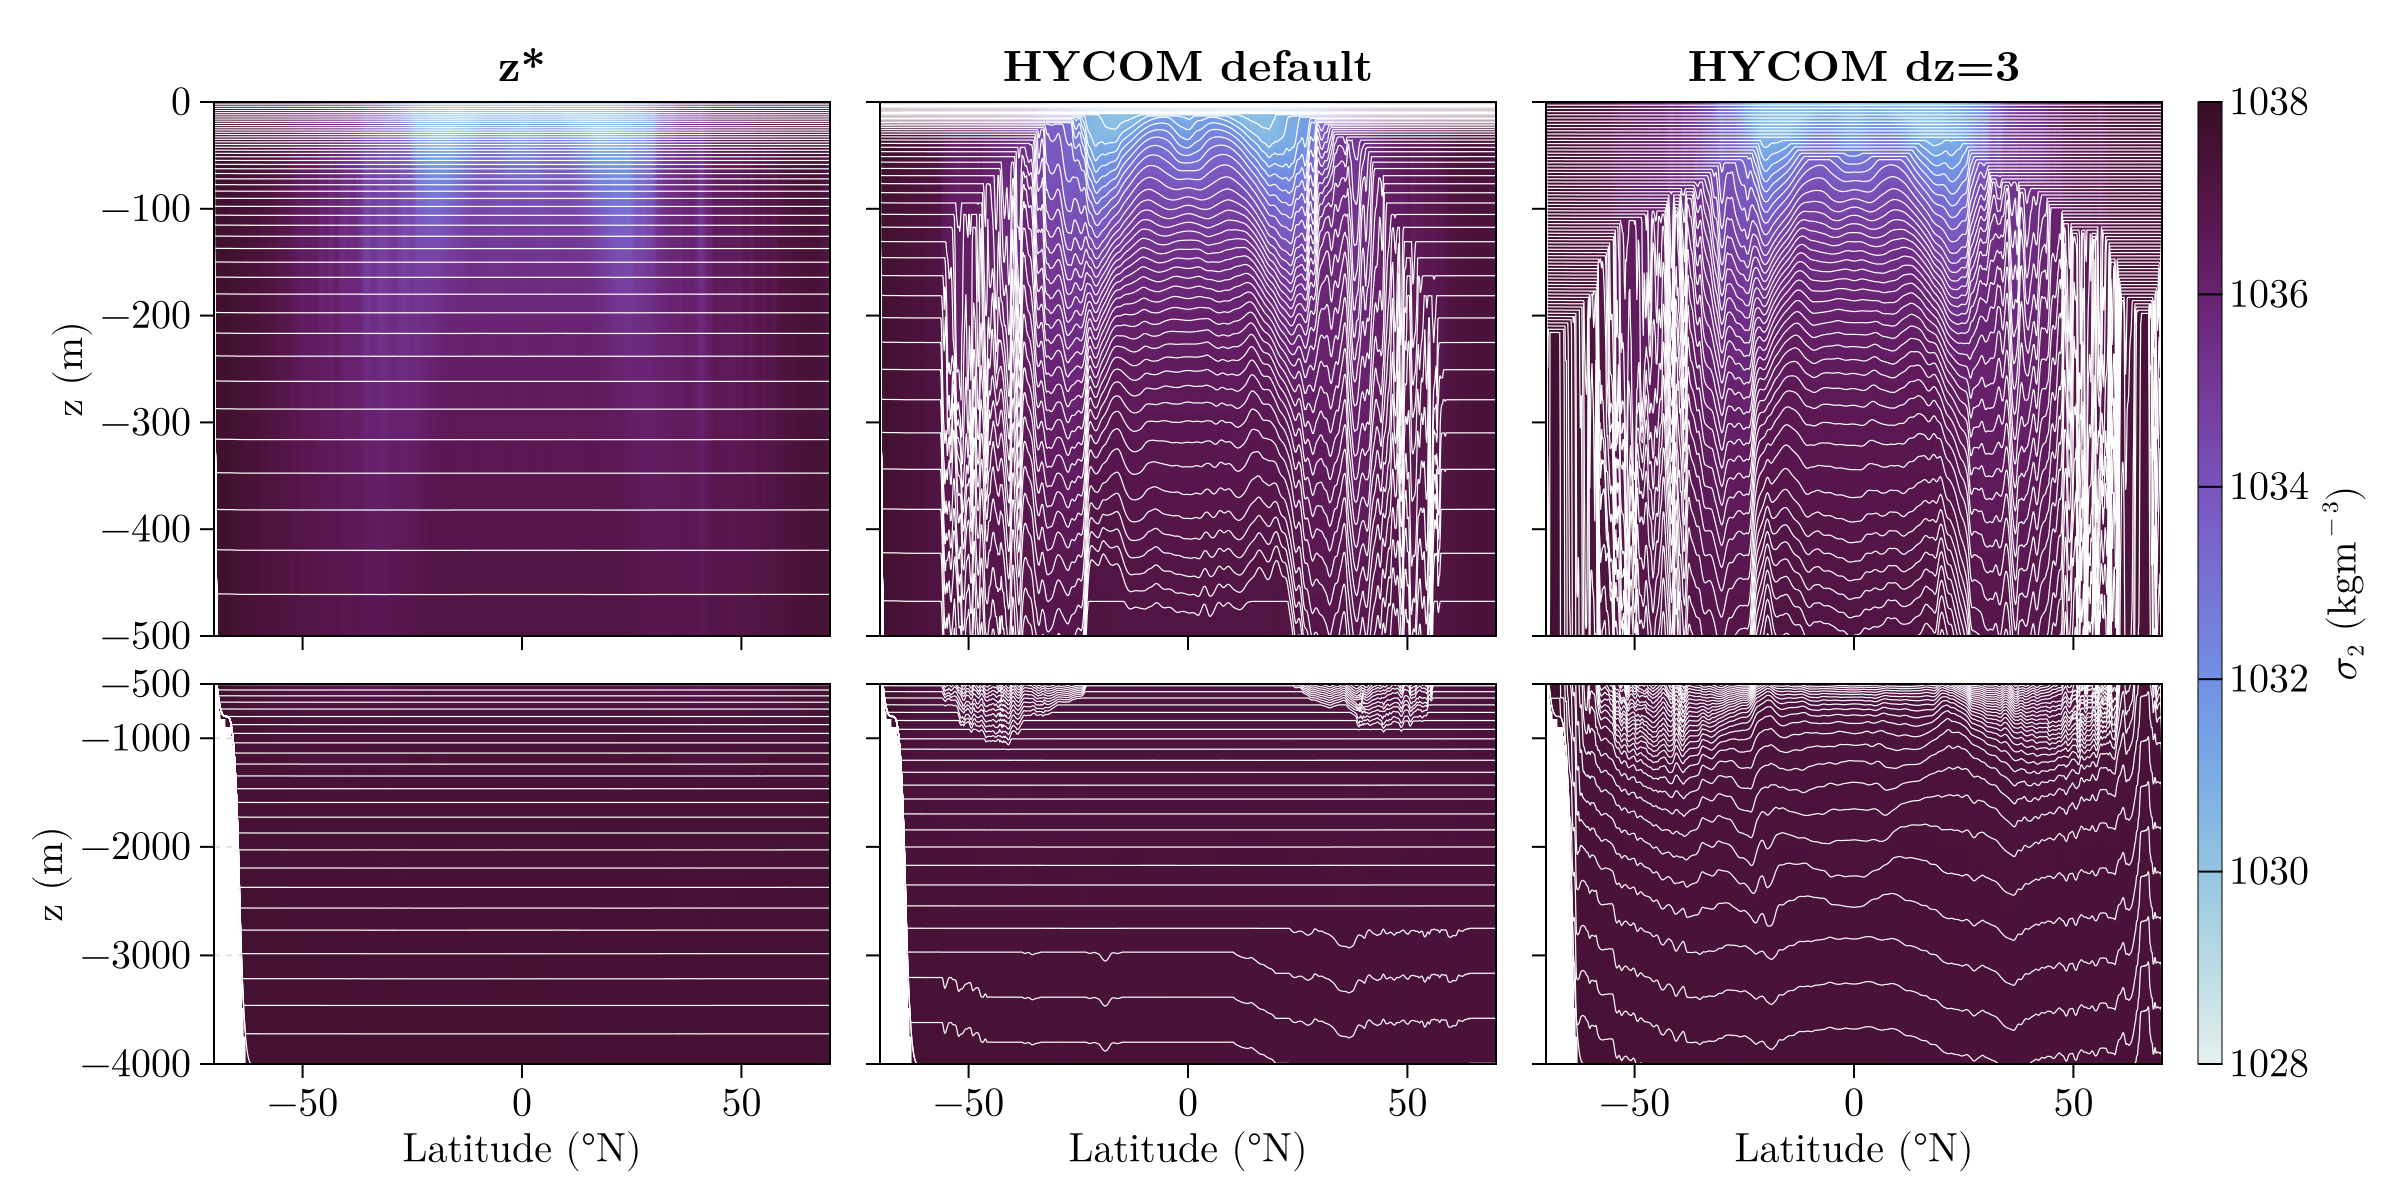

In [3]:
fig = Figure(size = (1200, 600))

titles = ("z*", "HYCOM default", "HYCOM dz=3")
colormap = :dense
colorrange = (1028, 1038)
depth_levels = 1:75

for (j, k) ∈ enumerate(expts)
    
    crs = get_geo_coords(catalogue[k]["static"], catalogue[k]["vc"])
    
    ds = NCDataset(catalogue[k]["monthly"], maskingvalue = NaN)
    h = ds["thkcello"][80, :, :, end] # middle of domain
    close(ds)

    ∫h = cumsum(h, dims = 2)
    
    ds = NCDataset(catalogue[k]["monthlyz"], maskingvalue = NaN)
    σ₂ = ds["rhopot2"][80, :, :, end] # middle of domain
    zl = -ds["z_l"][:]
    close(ds)

    axtop = Axis(fig[1, j], xlabel = "Latitude (°N)", ylabel = "z (m)", title = titles[j])
    hidexdecorations!(axtop, ticks = false)
    hm = heatmap!(axtop, crs.lath, zl, σ₂; colorrange, colormap)
    for i ∈ depth_levels
        lines!(axtop, crs.lath, -∫h[:, i], color = :white, linewidth = 0.6)
    end
    ylims!(axtop, -500, 0)
    axbot = Axis(fig[2, j], xlabel = "Latitude (°N)", ylabel = "z (m)")
    hm = heatmap!(axbot, crs.lath, zl, σ₂; colorrange, colormap)
    for i ∈ depth_levels
        lines!(axbot, crs.lath, -∫h[:, i], color = :white, linewidth = 0.6)
    end
    ylims!(axbot, -4000, -500)
    axbot.yticks = [-4000, -3000, -2000, -1000, -500]
    if j > 1
        hideydecorations!(axtop, ticks = false)
        hideydecorations!(axbot, ticks = false) 
    end
    if  j == 3 
        Colorbar(fig[1:2, j+1], hm, label = L"$σ_{2}$ (kgm$^{-3}$)")
    end

end
rowsize!(fig.layout, 1, Relative(1.75/3))
fig

In [10]:
save("rhopot2_transect_with_coord_surfaces.png", fig)

## Temperature transect

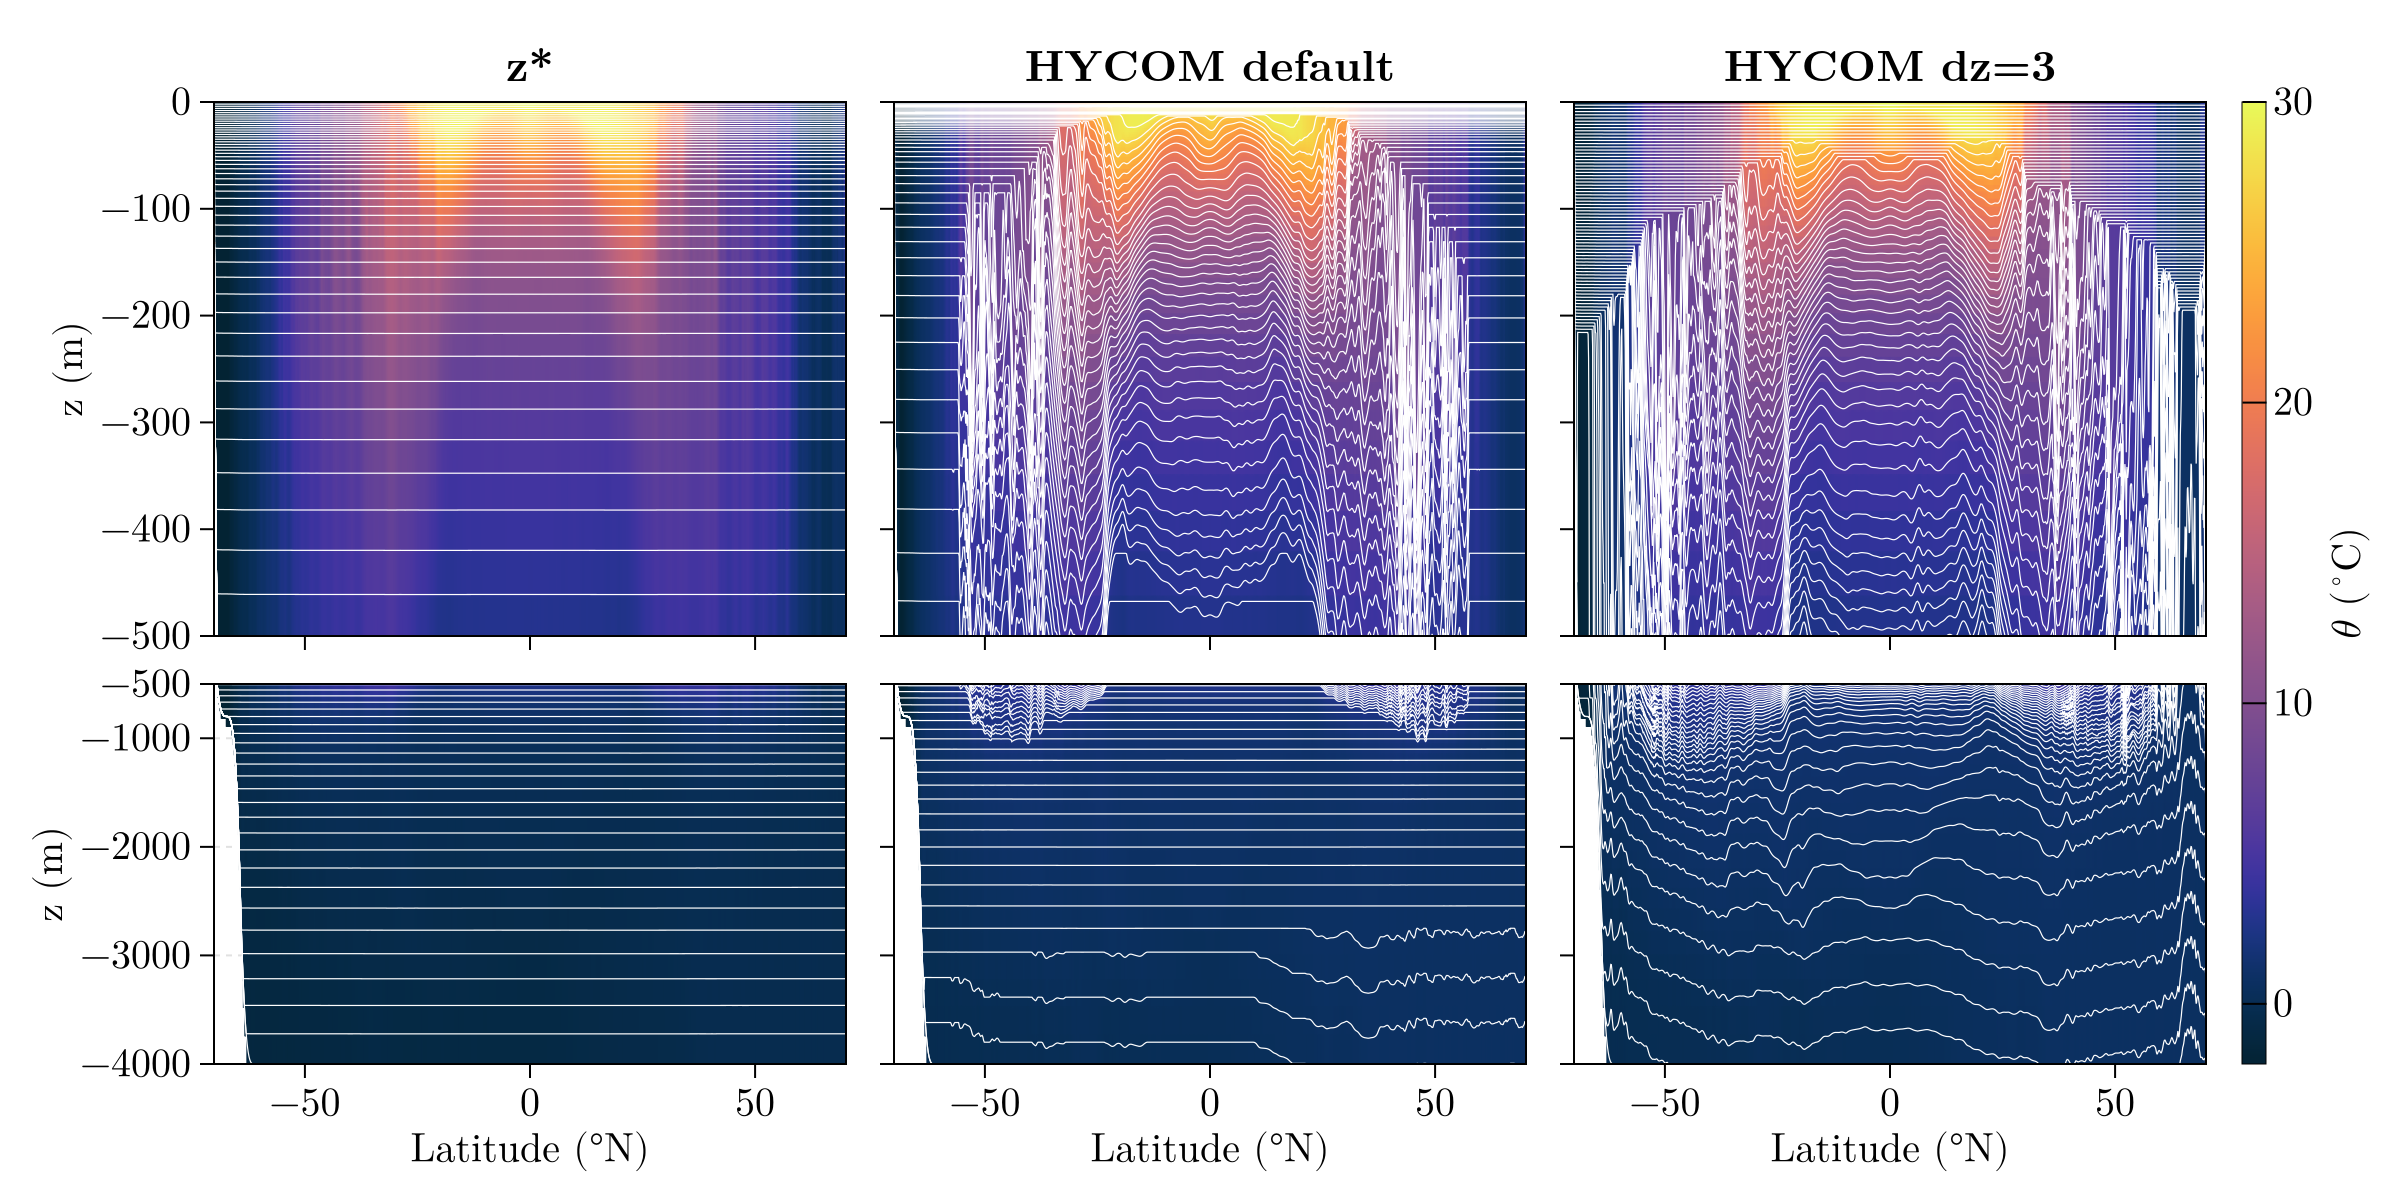

In [7]:
fig = Figure(size = (1200, 600))

titles = ("z*", "HYCOM default", "HYCOM dz=3")
colormap = :thermal
colorrange = (-2, 30)
depth_levels = 1:75

for (j, k) ∈ enumerate(expts)
    
    crs = get_geo_coords(catalogue[k]["static"], catalogue[k]["vc"])
    
    ds = NCDataset(catalogue[k]["monthly"], maskingvalue = NaN)
    h = ds["thkcello"][80, :, :, end] # middle of domain
    close(ds)

    ∫h = cumsum(h, dims = 2)
    
    ds = NCDataset(catalogue[k]["monthlyz"], maskingvalue = NaN)
    θ = ds["thetao"][80, :, :, end] # middle of domain
    zl = -ds["z_l"][:]
    close(ds)

    axtop = Axis(fig[1, j], xlabel = "Latitude (°N)", ylabel = "z (m)", title = titles[j])
    hidexdecorations!(axtop, ticks = false)
    hm = heatmap!(axtop, crs.lath, zl, θ; colorrange, colormap)
    for i ∈ depth_levels
        lines!(axtop, crs.lath, -∫h[:, i], color = :white, linewidth = 0.6)
    end
    ylims!(axtop, -500, 0)
    axbot = Axis(fig[2, j], xlabel = "Latitude (°N)", ylabel = "z (m)")
    hm = heatmap!(axbot, crs.lath, zl, θ; colorrange, colormap)
    for i ∈ depth_levels
        lines!(axbot, crs.lath, -∫h[:, i], color = :white, linewidth = 0.6)
    end
    ylims!(axbot, -4000, -500)
    axbot.yticks = [-4000, -3000, -2000, -1000, -500]
    if j > 1
        hideydecorations!(axtop, ticks = false)
        hideydecorations!(axbot, ticks = false) 
    end
    if  j == 3 
        Colorbar(fig[1:2, j+1], hm, label = L"$\theta$ ($^{\circ}$C)")
    end

end
rowsize!(fig.layout, 1, Relative(1.75/3))
fig

In [ ]:
save("theta_transect_with_coord_surfaces.png", fig)